# Linear Regression 

### 1. The Linear Model
The goal is to find a relationship between the input features $X$ and the target $y$. This is represented by the linear equation:

$$\hat{y} = X \cdot w + b$$



| Variable | Description | Shape |
| :--- | :--- | :--- |
| $X$ | Input matrix | $(n_{samples}, n_{features})$ |
| $w$ | Weight vector (parameters) | $(n_{features}, 1)$ |
| $b$ | Bias (intercept) scalar | Scalar |
| $\hat{y}$ | Predicted values | $(n_{samples}, 1)$ |


### 2. The Cost Function (MSE)
To quantify the error of our model, we use **Mean Squared Error (MSE)**. This calculates the average of the squared differences between the predicted values ($\hat{y}$) and the actual values ($y$):

$$J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$



### 3. The Gradients (The "Direction")
To minimize the error, we calculate the partial derivatives (gradients) of the cost function $J$. This tells us how to adjust $w$ and $b$ to reduce the error.



* **Gradient with respect to Weights ($dw$):**
    $$dw = \frac{\partial J}{\partial w} = \frac{1}{n} X^T \cdot (\hat{y} - y)$$
* **Gradient with respect to Bias ($db$):**
    $$db = \frac{\partial J}{\partial b} = \frac{1}{n} \sum (\hat{y} - y)$$

**Note:** In code, $(\hat{y} - y)$ is the error vector. Multiplying by the transpose $X^T$ determines how much each feature contributed to that specific error.



### 4. The Update Rule
Once we have the gradients (the "uphill" direction), we update the weights in the **opposite direction** (downhill) to minimize the cost.

$$w = w - (\alpha \cdot dw)$$
$$b = b - (\alpha \cdot db)$$

* **$\alpha$ (Learning Rate):** A small constant (e.g., $0.01$) that controls the size of the step we take.


In [1]:
import numpy as np

class LinearRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        #initialize parameters, set w and b to zero.
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        #gradient descent
        for _ in range(self.iterations):
            #predict current values (y = wx + b)
            y_predicted = np.dot(X, self.weights) + self.bias

            #calculate gradients (derivatives), step 3
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            #update weights and bias, step 4
            self.weights = self.weights - self.lr * dw
            self.bias = self.bias - self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [2]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

MSE:  380.1306497140645


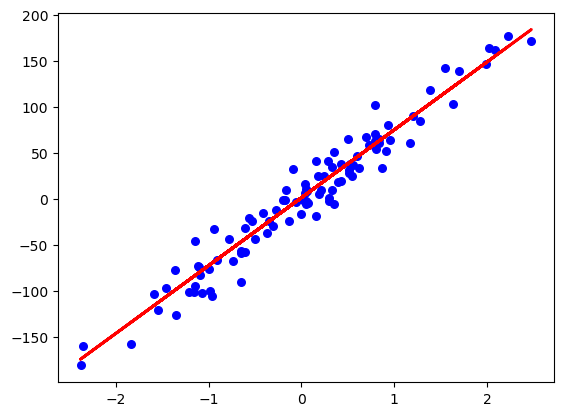

In [3]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

X, y = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

model = LinearRegression(learning_rate=0.01, iterations=1000)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print("MSE: ", mean_squared_error(y_test,predictions))

plt.scatter(X, y, color="blue", s=30)
plt.plot(X, model.predict(X), color="red", linewidth=2, label="Prediction")
plt.show()

#### TODO: Test your implementation using the data from https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview. Then, compare your results against the Scikit-Learn implementation.

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as SklearnLR
from sklearn.metrics import mean_squared_error

df = pd.read_csv('train.csv')

df_numeric = df.select_dtypes(include=[np.number])

df_numeric = df_numeric.fillna(df_numeric.mean())

X = df_numeric.drop('SalePrice', axis=1).values
y = df_numeric['SalePrice'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training manual model...")
my_model = LinearRegression(learning_rate=0.01, iterations=2000) 
my_model.fit(X_train_scaled, y_train)
my_predictions = my_model.predict(X_test_scaled)
my_mse = mean_squared_error(y_test, my_predictions)

# SCIKIT-LEARN 
print("Training Scikit-Learn model...")
sklearn_model = SklearnLR()
sklearn_model.fit(X_train_scaled, y_train)
sklearn_predictions = sklearn_model.predict(X_test_scaled)
sklearn_mse = mean_squared_error(y_test, sklearn_predictions)

print("\n" + "="*30)
print(f"MSE Manual Model:       {my_mse:,.0f}")
print(f"MSE Scikit-Learn:      {sklearn_mse:,.0f}")
print("="*30)

if my_mse < 2 * sklearn_mse:
    print("Success! The manual model is performing well.")
else:
    print("Something is off. Check the learning rate or number of iterations.")

Training manual model...
Training Scikit-Learn model...

MSE Manual Model:       1,359,637,270
MSE Scikit-Learn:      1,360,900,005
Success! The manual model is performing well.
